# Daily Challenge: Building Your First Neural Network on the MNIST Dataset

1. Load and Preprocess the MNIST Dataset

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Load the MNIST dataset using TensorFlow/Keras
(x_train_data, y_train_data), (x_val_data, y_val_data) = keras.datasets.fashion_mnist.load_data()

In [3]:
# Normalize the image pixel values to be between 0 and 1
def preprocessing_function(x_new, y_new):
  x_new = tf.cast(x_new, tf.float32) / 255.0  # Normalize pixel values
  y_new = tf.cast(y_new, tf.int64)            # Convert labels to integers
  return x_new, y_new

# Convert labels into one-hot encoded format
def func_creating_dataset(xs_data, ys_data, num_classes=10):
  ys_data = tf.one_hot(ys_data, depth=num_classes)  # One-hot encode labels
  return tf.data.Dataset.from_tensor_slices((xs_data, ys_data)) \
    .map(preprocessing_function) \
    .shuffle(buffer_size=1000) \
    .batch(32)

# Create the training and validation datasets using func_creating_dataset
dataset_training = func_creating_dataset(x_train_data, y_train_data) # Creating the training dataset
dataset_val = func_creating_dataset(x_val_data, y_val_data)       # Creating the validation dataset

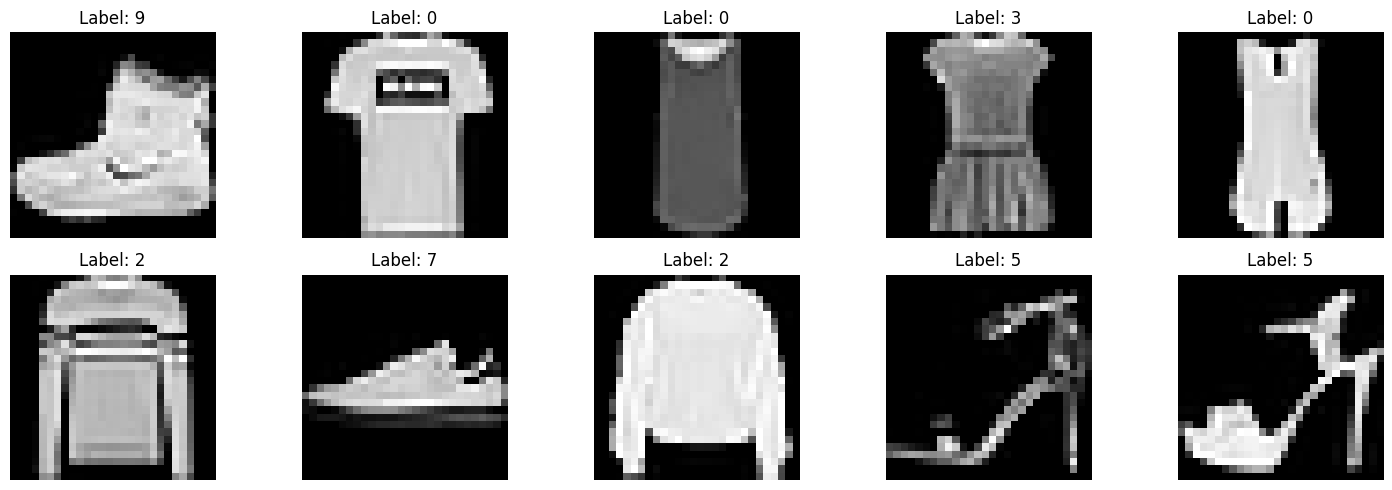

In [6]:
# Display sample images with their corresponding labels
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_data[i], cmap='gray')
    plt.title(f"Label: {y_train_data[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()



2. Build a Fully Connected Neural Network



In [25]:
# Define a sequential model using Keras
model = keras.Sequential([
    keras.layers.Reshape(target_shape=(28 * 28,), input_shape=(28, 28)),  # Flatten the 28x28 images into 1D vectors
    keras.layers.Dense(256, activation='relu'),   # Hidden layer with 256 neurons and ReLU activation
    keras.layers.Dense(192, activation='relu'),   # Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(128, activation='relu'),   # Hidden layer with 64 neurons and ReLU activation
    keras.layers.Dense(10, activation='softmax')  # Output layer with 10 neurons (one for each class) and softmax activation
])

In [26]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
                metrics=['accuracy'])

3. Train the Neural Network

In [27]:
# Fit the model to the training data for 10 epochs
model.fit(dataset_training, epochs=10, validation_data=dataset_val)

# Compute accuracy on the test dataset
val_loss, val_accuracy = model.evaluate(dataset_val)
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")


Epoch 1/10


1875/1875 [==============================] - 22s 10ms/step - loss: 0.4798 - accuracy: 0.8250 - val_loss: 0.4450 - val_accuracy: 0.8390
Epoch 2/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.3635 - accuracy: 0.8676 - val_loss: 0.3796 - val_accuracy: 0.8621
Epoch 3/10
1875/1875 [==============================] - 18s 10ms/step - loss: 0.3277 - accuracy: 0.8783 - val_loss: 0.4412 - val_accuracy: 0.8441
Epoch 4/10
1875/1875 [==============================] - 18s 9ms/step - loss: 0.3036 - accuracy: 0.8881 - val_loss: 0.3576 - val_accuracy: 0.8711
Epoch 5/10
1875/1875 [==============================] - 18s 10ms/step - loss: 0.2855 - accuracy: 0.8939 - val_loss: 0.3387 - val_accuracy: 0.8786
Epoch 6/10
1875/1875 [==============================] - 18s 10ms/step - loss: 0.2717 - accuracy: 0.8976 - val_loss: 0.3597 - val_accuracy: 0.8768
Epoch 7/10
1875/1875 [==============================] - 20s 10ms/step - loss: 0.2591 - accuracy: 0.9027 - val_loss: 0.3498 - val_accurac

4. Evaluate the Model’s Performance

313/313 [==============================] - 2s 6ms/step


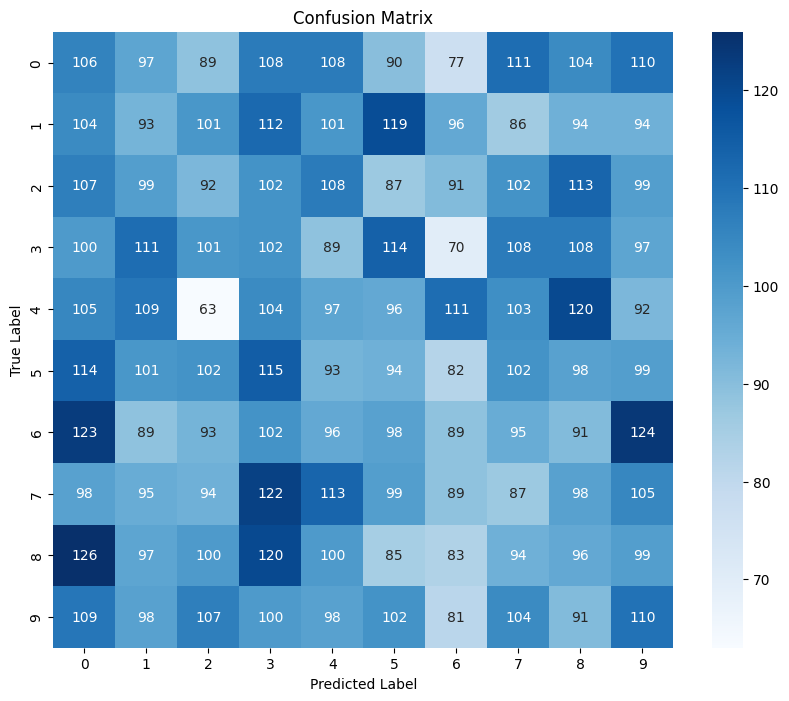

In [28]:
# Display a confusion matrix for misclassified digits
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get true labels and predictions
y_pred_probs = model.predict(dataset_val)
y_pred = np.argmax(y_pred_probs, axis=1)
# Compute confusion matrix

# Get true labels from the validation data (original labels before one-hot encoding)
y_true = y_val_data  # These are the original labels (0-9)

cm = confusion_matrix(y_true, y_pred)
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10),
            yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()